In [52]:
import matplotlib.pyplot as plt
import numpy as np

In [24]:
soc = []
v = []

SoC = 1.0   # normalized

T = 300000    # longer simulation to see curve

E0 = 3.7
K = 0.1
R0 = 0.05
Q = 2.5
dt = 1      # seconds

for t in range(T):

    P = 5  # realistic power

    i = P / E0

    for _ in range(5):
        V = E0 - K*(1-SoC)/max(SoC, 0.05) - R0*i
        i = P / V

    # correct unit conversion
    SoC = SoC - (i * dt / 3600 / Q)

    if SoC <= 0.1:
        break

    soc.append(SoC)
    v.append(V)

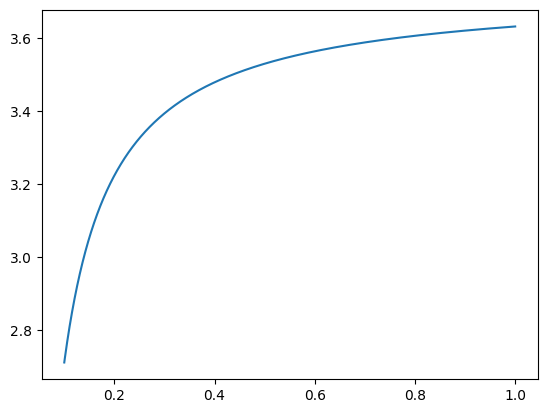

In [27]:
plt.plot(soc,v)

In [30]:
soc = []
v = []

SoC = 1.0

E0 = 3.7
K = 1.0
R0 = 0.01
Q = 2.5
dt = 1

for t in range(10000):

    i = 1.0   # constant current (IMPORTANT)

    V = E0 - K*(1-SoC)/max(SoC, 0.05) - R0*i

    SoC = SoC - (i * dt / 3600 / Q)

    soc.append(SoC)

    v.append(V)

    if SoC <= 0.05:
        break
        

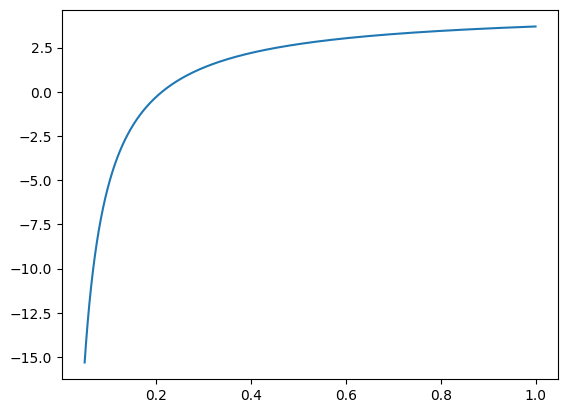

In [32]:
plt.plot(soc, v)

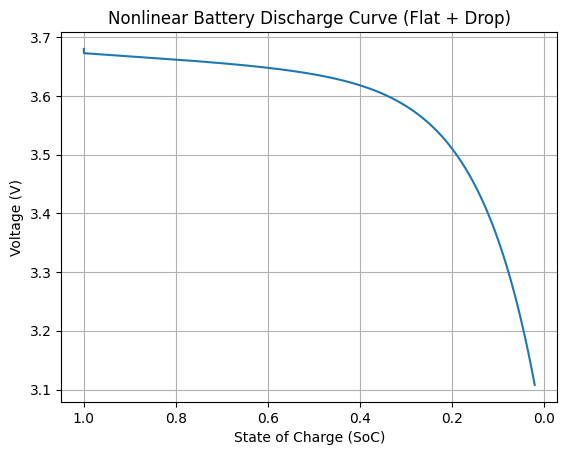

In [37]:
import math
import matplotlib.pyplot as plt

# -----------------------------
# Parameters
# -----------------------------
E0 = 3.7        # nominal voltage
R0 = 0.02       # internal resistance
Q = 2.5         # capacity (Ah)

# Nonlinear voltage model parameters (tuned for realistic curve)
K1 = 0.05       # linear slope
K2 = 0.6        # exponential strength
K3 = 8          # exponential sharpness

dt = 1          # time step (seconds)
T = 20000       # simulation length

# Constant current discharge (simpler + clearer nonlinearity)
i = 1.0         # Amps

# -----------------------------
# Initialization
# -----------------------------
SoC = 1.0

soc_list = []
voltage_list = []

# -----------------------------
# Simulation loop
# -----------------------------
for t in range(T):

    # Nonlinear voltage model (flat + sharp drop)
    V = E0 - R0*i - K1*(1-SoC) - K2*math.exp(-K3*SoC)

    # Prevent unrealistic voltage
    V = max(V, 2.5)

    i = P / V

    # Update SoC (convert sec → hours)
    SoC = SoC - (i * dt / 3600 / Q)

    # Store data
    soc_list.append(SoC)
    voltage_list.append(V)

    # Stop at low SoC
    if SoC <= 0.02:
        break

# -----------------------------
# Plot: SoC vs Voltage
# -----------------------------
plt.figure()
plt.plot(soc_list, voltage_list)
plt.xlabel("State of Charge (SoC)")
plt.ylabel("Voltage (V)")
plt.title("Nonlinear Battery Discharge Curve (Flat + Drop)")
plt.grid()

# Reverse x-axis (SoC from 1 → 0 like papers)
plt.gca().invert_xaxis()

plt.show()

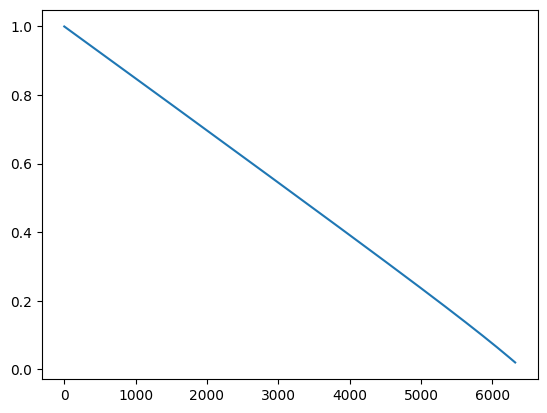

In [38]:
plt.plot(soc_list)

In [39]:
import pybamm

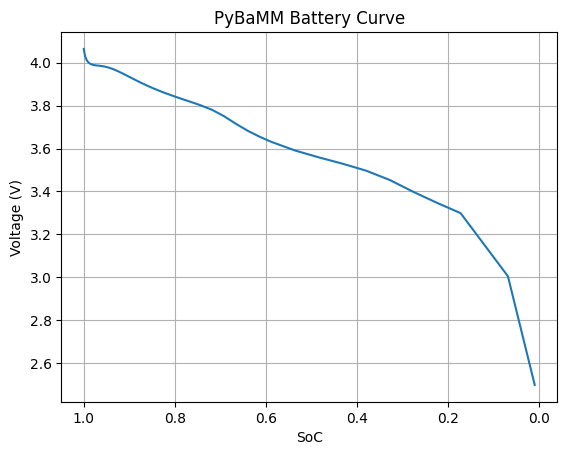

In [47]:
import matplotlib.pyplot as plt

# -----------------------------
# Create model
# -----------------------------
model = pybamm.lithium_ion.SPM()  
# SPM = Single Particle Model (fast + nonlinear)

# -----------------------------
# Load parameters (includes OCV curve)
# -----------------------------
param = pybamm.ParameterValues("Chen2020")

# -----------------------------
# Simulation (constant current discharge)
# -----------------------------
sim = pybamm.Simulation(model, parameter_values=param)

# Run for 1 hour
solution = sim.solve([0, 3600])

# -----------------------------
# Extract variables
# -----------------------------
time = solution["Time [s]"].entries
voltage = solution["Terminal voltage [V]"].entries

capacity = solution["Discharge capacity [A.h]"].entries
Q = param["Nominal cell capacity [A.h]"]

soc = 1 - capacity / Q

#soc = solution["State of Charge"].entries

# -----------------------------
# Plot SoC vs Voltage
# -----------------------------
plt.plot(soc, voltage)
plt.xlabel("SoC")
plt.ylabel("Voltage (V)")
plt.title("PyBaMM Battery Curve")
plt.gca().invert_xaxis()
plt.grid()
plt.show()

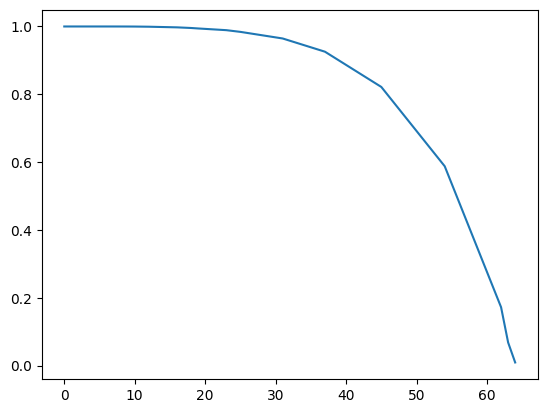

In [48]:
plt.plot(soc)

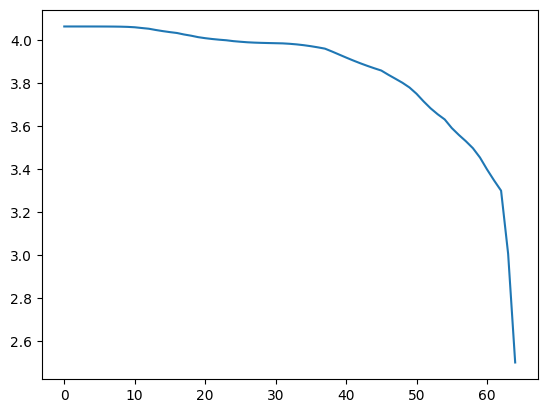

In [50]:
plt.plot(voltage)

In [53]:
np.save("soc.npy", soc)
np.save("ocv.npy", voltage)

In [54]:
soc_table = np.load("soc.npy")
ocv_table = np.load("ocv.npy")

# sort (important)
idx = np.argsort(soc_table)
soc_table = soc_table[idx]
ocv_table = ocv_table[idx]

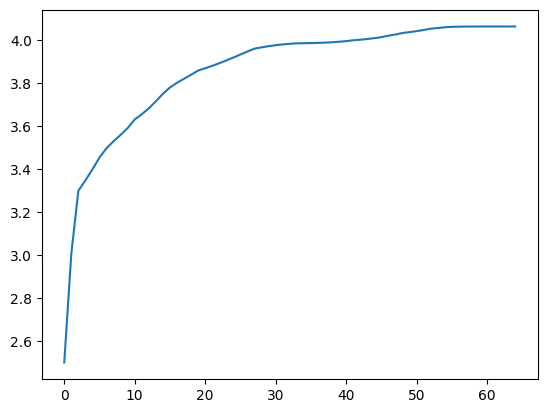

In [56]:
plt.plot(ocv_table)

In [57]:
def get_ocv(soc):
    return np.interp(soc, soc_table, ocv_table)

In [60]:
import enum

class Mode_Of_Operation(enum.Enum):
    Charge_Mode = 0
    Work_Mode = 1
    Queue_Mode = 2
    Off_Mode = 3
    On_Mode = 4

In [124]:
def update_battery(battery_percentage, mode=Mode_Of_Operation.Work_Mode):

    dt = 1
    R0 = 0.005
    
    Q = 20.0  # your robot battery

    # Convert %
    soc = battery_percentage / 100.0
    soc = max(0.05, min(1.0, soc))

    # Power model
    if mode == Mode_Of_Operation.Work_Mode:
        P = 150
    else:
        P = 20

    # Solve current (nonlinear)
    i = P / 3.7
    # i = P / get_ocv(soc)
    V = get_ocv(soc)
    for _ in range(5):
        V = get_ocv(soc) - R0 * i
        V = max(V, 2.5)
        i = P / V

    # Update SoC
    soc = soc - (i * dt / 3600 / Q)

    # Convert back
    battery_percentage = soc * 100.0
    battery_percentage = min(100.0, max(0.0, battery_percentage))

    return battery_percentage, V

In [125]:
battery_percentage = 100.
battery = []
voltage = []
for i in range(2300):
    battery_percentage, v = update_battery(battery_percentage)
    battery.append(battery_percentage)
    voltage.append(v)

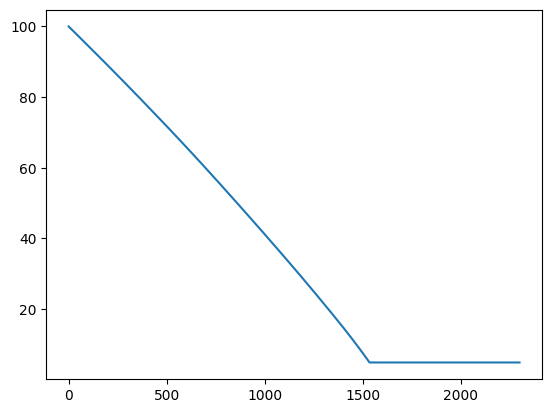

In [126]:
plt.plot(battery)

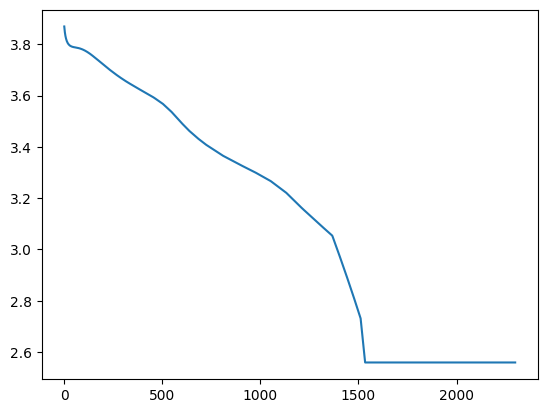

In [127]:
plt.plot(voltage)

In [129]:
import numpy as np
import math


class Mode_Of_Operation:
    Work_Mode = 1
    Idle_Mode = 0


class BatteryModel:

    def __init__(self, capacity_ah=20.0):
        self.Q = capacity_ah  # Ah
        self.battery_percentage = 100.0
        self.v_rc = 0.0
        self.time = 0.0

        # -----------------------------
        # Realistic Li-ion OCV curve
        # -----------------------------
        self.soc_table = np.load("soc.npy")

        self.ocv_table = np.load("ocv.npy")

    # -----------------------------
    # OCV from lookup
    # -----------------------------
    def get_ocv(self, soc):
        return np.interp(soc, self.soc_table, self.ocv_table)

    # -----------------------------
    # SoC-dependent resistance
    # -----------------------------
    def get_r0(self, soc):
        return 0.02 + 0.05 * (1 - soc)**2

    # -----------------------------
    # Main update
    # -----------------------------
    def update(self, mode=Mode_Of_Operation.Work_Mode, dt=1.0):

        soc = self.battery_percentage / 100.0

        # -----------------------------
        # Robot power model (dynamic!)
        # -----------------------------
        if mode == Mode_Of_Operation.Work_Mode:
            base = 120
            dynamic = 40 * abs(math.sin(self.time / 5.0))
            P = base + dynamic
        else:
            P = 20

        # -----------------------------
        # RC transient parameters
        # -----------------------------
        R1 = 0.03
        C1 = 1500.0
        tau = R1 * C1

        # -----------------------------
        # Solve current (nonlinear)
        # -----------------------------
        i = P / 3.7  # initial guess

        for _ in range(8):
            ocv = self.get_ocv(soc)
            r0 = self.get_r0(soc)

            V = ocv - r0 * i - self.v_rc
            V = max(V, 2.5)

            i = P / V

        # -----------------------------
        # Update RC voltage (lag effect)
        # -----------------------------
        self.v_rc += dt * (i * R1 - self.v_rc) / tau

        # -----------------------------
        # Update SoC
        # -----------------------------
        soc -= (i * dt / 3600.0 / self.Q)

        # Clamp AFTER update
        soc = max(0.0, min(1.0, soc))
        self.battery_percentage = soc * 100.0

        # Advance time
        self.time += dt

        return self.battery_percentage, V, i

In [130]:
a = BatteryModel()

In [131]:
a.battery_percentage

100.0

In [132]:
battery = []
for i in range(2000):
    a.update()
    battery.append(a.battery_percentage)

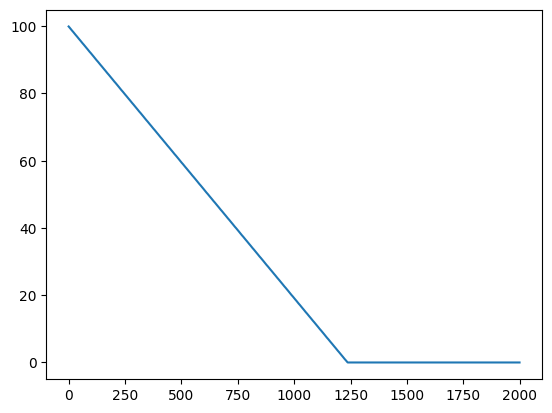

In [133]:
plt.plot(battery)

In [143]:
battery_charge_model_file = "./battery_charge_scheduling/" + '/models/battery_discharge_model.yaml'
with open(file=battery_charge_model_file, mode="r", encoding='utf-8') as f:
    for line in f.readlines():
        print(line)

In [145]:
import random

In [146]:
def round_off_add_to_one(data:list, decimal_place=2):
        """ Step 1: Round each probability to {decimal_place} decimals
            Step 2: Compute the difference from 1.
        Args:
            data (list): _description_
        """
        normalize_data = np.array(data)/np.sum(data)
        round_data = np.round(normalize_data, decimal_place)
        diff = round((1 - np.sum(round_data)) * 10**(decimal_place))
        
        sorted_rounded = np.argsort(round_data)
        small_diff = np.round(np.power(0.1, decimal_place), decimal_place)
        for i in range(abs(diff)):
            idx =  sorted_rounded[i % len(round_data)]
            if diff > 0:
                round_data[idx] += small_diff
            else:
                round_data[idx] -= small_diff
        return round_data

In [144]:
charging_model = {0: {15: 12, 14: 5, 16: 3}, 1: {16: 4, 17: 8, 15: 8}, 2: {17: 7, 16: 9, 18: 4}, 3: {18: 5, 17: 9, 19: 6}, 4: {19: 8, 18: 8, 20: 4}, 5: {20: 6, 19: 5, 21: 9}, 6: {22: 5, 21: 6, 20: 9}, 7: {23: 5, 22: 10, 21: 5}, 8: {23: 7, 22: 10, 24: 3}, 9: {24: 8, 25: 5, 23: 7}, 10: {26: 11, 25: 8, 24: 1}, 11: {26: 7, 27: 6, 25: 7}, 12: {27: 8, 26: 5, 28: 7}, 13: {27: 7, 28: 5, 29: 8}, 14: {30: 10, 28: 6, 29: 4}, 15: {29: 7, 30: 3, 31: 10}, 16: {32: 3, 31: 10, 30: 7}, 17: {31: 6, 33: 10, 32: 4}, 18: {34: 7, 33: 7, 32: 6}, 19: {34: 9, 35: 6, 33: 5}, 20: {35: 5, 36: 12, 34: 3}, 21: {37: 11, 36: 6, 35: 3}, 22: {36: 6, 38: 5, 37: 9}, 23: {39: 10, 37: 5, 38: 5}, 24: {38: 6, 39: 7, 40: 7}, 25: {40: 9, 41: 6, 39: 5}, 26: {40: 9, 41: 8, 42: 3}, 27: {42: 8, 41: 7, 43: 5}, 28: {42: 8, 44: 6, 43: 6}, 29: {45: 7, 44: 6, 43: 7}, 30: {45: 7, 46: 7, 44: 6}, 31: {46: 3, 45: 11, 47: 6}, 32: {46: 11, 48: 3, 47: 6}, 33: {49: 6, 48: 8, 47: 6}, 34: {48: 4, 50: 12, 49: 4}, 35: {51: 10, 50: 5, 49: 5}, 36: {52: 9, 50: 4, 51: 7}, 37: {52: 7, 53: 7, 51: 6}, 38: {52: 11, 54: 6, 53: 3}, 39: {54: 8, 55: 6, 53: 6}, 40: {56: 6, 55: 5, 54: 9}, 41: {56: 6, 55: 7, 57: 7}, 42: {56: 6, 57: 9, 58: 5}, 43: {58: 6, 57: 6, 59: 8}, 44: {60: 9, 58: 9, 59: 2}, 45: {60: 11, 61: 3, 59: 6}, 46: {61: 9, 60: 6, 62: 5}, 47: {62: 9, 63: 7, 61: 4}, 48: {63: 5, 62: 9, 64: 6}, 49: {64: 5, 63: 9, 65: 6}, 50: {66: 7, 65: 6, 64: 7}, 51: {65: 6, 66: 8, 67: 6}, 52: {68: 7, 66: 9, 67: 4}, 53: {69: 9, 68: 6, 67: 5}, 54: {69: 5, 70: 7, 68: 8}, 55: {71: 7, 69: 5, 70: 8}, 56: {70: 9, 71: 6, 72: 5}, 57: {71: 10, 73: 5, 72: 5}, 58: {74: 4, 72: 11, 73: 5}, 59: {73: 8, 75: 9, 74: 3}, 60: {75: 8, 74: 8, 76: 4}, 61: {75: 6, 77: 6, 76: 8}, 62: {76: 11, 78: 3, 77: 6}, 63: {78: 7, 79: 8, 77: 5}, 64: {79: 9, 80: 6, 78: 5}, 65: {79: 9, 81: 8, 80: 3}, 66: {81: 8, 82: 8, 80: 4}, 67: {83: 7, 82: 6, 81: 7}, 68: {82: 9, 84: 3, 83: 8}, 69: {83: 8, 85: 7, 84: 5}, 70: {84: 4, 85: 7, 86: 9}, 71: {87: 6, 85: 8, 86: 6}, 72: {86: 4, 88: 7, 87: 9}, 73: {87: 10, 88: 4, 89: 6}, 74: {88: 9, 89: 10, 90: 1}, 75: {90: 9, 91: 6, 89: 5}, 76: {92: 6, 90: 9, 91: 5}, 77: {93: 12, 91: 3, 92: 5}, 78: {92: 6, 94: 6, 93: 8}, 79: {93: 7, 95: 8, 94: 5}, 80: {95: 10, 94: 7, 96: 3}, 81: {95: 6, 97: 9, 96: 5}, 82: {98: 8, 96: 9, 97: 3}, 83: {98: 7, 99: 7, 97: 6}, 84: {99: 7, 98: 5, 100: 8}, 85: {100: 14, 99: 6}, 86: {100: 20}, 87: {100: 20}, 88: {100: 20}, 89: {100: 20}, 90: {100: 20}, 91: {100: 20}, 92: {100: 20}, 93: {100: 20}, 94: {100: 20}, 95: {100: 20}, 96: {100: 20}, 97: {100: 20}, 98: {100: 20}, 99: {100: 20}, 100: {100: 20}}
discharge_model = {0: {0: 20}, 1: {0: 20}, 2: {0: 20}, 3: {0: 12, 2: 8}, 4: {2: 14, 0: 6}, 5: {2: 15, 4: 5}, 6: {4: 15, 2: 5}, 7: {4: 13, 6: 7}, 8: {4: 6, 6: 14}, 9: {6: 14, 8: 6}, 10: {8: 16, 6: 4}, 11: {8: 15, 10: 5}, 12: {10: 13, 8: 7}, 13: {10: 16, 12: 4}, 14: {12: 11, 10: 9}, 15: {14: 8, 12: 12}, 16: {14: 15, 12: 5}, 17: {14: 13, 16: 7}, 18: {16: 14, 14: 6}, 19: {16: 13, 18: 7}, 20: {18: 10, 16: 10}, 21: {18: 12, 20: 8}, 22: {20: 15, 18: 5}, 23: {20: 11, 22: 9}, 24: {20: 5, 22: 15}, 25: {22: 14, 24: 6}, 26: {24: 11, 22: 9}, 27: {24: 13, 26: 7}, 28: {24: 12, 26: 8}, 29: {26: 9, 28: 11}, 30: {26: 5, 28: 15}, 31: {28: 14, 30: 6}, 32: {30: 16, 28: 4}, 33: {30: 12, 32: 8}, 34: {32: 15, 30: 5}, 35: {32: 14, 34: 6}, 36: {34: 15, 32: 5}, 37: {34: 13, 36: 7}, 38: {36: 15, 34: 5}, 39: {36: 17, 38: 3}, 40: {36: 6, 38: 14}, 41: {38: 12, 40: 8}, 42: {38: 10, 40: 10}, 43: {42: 7, 40: 13}, 44: {42: 13, 40: 7}, 45: {44: 8, 42: 12}, 46: {44: 15, 42: 5}, 47: {46: 10, 44: 10}, 48: {44: 8, 46: 12}, 49: {46: 12, 48: 8}, 50: {48: 12, 46: 8}, 51: {48: 10, 50: 10}, 52: {48: 8, 50: 12}, 53: {50: 10, 52: 10}, 54: {52: 15, 50: 5}, 55: {54: 11, 52: 9}, 56: {52: 5, 54: 15}, 57: {54: 16, 56: 4}, 58: {56: 16, 54: 4}, 59: {56: 14, 58: 6}, 60: {56: 5, 58: 15}, 61: {60: 7, 58: 13}, 62: {60: 17, 58: 3}, 63: {62: 10, 60: 10}, 64: {62: 12, 60: 8}, 65: {62: 12, 64: 8}, 66: {62: 6, 64: 14}, 67: {66: 11, 64: 9}, 68: {66: 11, 64: 9}, 69: {66: 13, 68: 7}, 70: {68: 13, 66: 7}, 71: {68: 12, 70: 8}, 72: {68: 9, 70: 11}, 73: {72: 8, 70: 12}, 74: {72: 13, 70: 7}, 75: {74: 11, 72: 9}, 76: {74: 10, 72: 10}, 77: {74: 15, 76: 5}, 78: {76: 14, 74: 6}, 79: {76: 13, 78: 7}, 80: {78: 16, 76: 4}, 81: {78: 13, 80: 7}, 82: {80: 13, 78: 7}, 83: {82: 11, 80: 9}, 84: {82: 18, 80: 2}, 85: {82: 16, 84: 4}, 86: {84: 12, 82: 8}, 87: {86: 8, 84: 12}, 88: {84: 10, 86: 10}, 89: {86: 13, 88: 7}, 90: {86: 4, 88: 16}, 91: {88: 13, 90: 7}, 92: {90: 15, 88: 5}, 93: {90: 14, 92: 6}, 94: {92: 15, 90: 5}, 95: {92: 15, 94: 5}, 96: {94: 11, 92: 9}, 97: {94: 13, 96: 7}, 98: {96: 13, 94: 7}, 99: {96: 14, 98: 6}, 100: {96: 7, 98: 13}}
go_charge_model = {0: {15: 10, 16: 5, 14: 5}, 1: {15: 7, 16: 7, 17: 6}, 2: {16: 6, 17: 10, 18: 4}, 3: {17: 5, 18: 8, 19: 7}, 4: {18: 5, 20: 6, 19: 9}, 5: {19: 10, 20: 5, 21: 5}, 6: {21: 8, 20: 3, 22: 9}, 7: {22: 5, 21: 7, 23: 8}, 8: {22: 8, 23: 6, 24: 6}, 9: {23: 7, 25: 3, 24: 10}, 10: {24: 7, 26: 8, 25: 5}, 11: {27: 9, 26: 8, 25: 3}, 12: {28: 11, 26: 4, 27: 5}, 13: {29: 10, 27: 8, 28: 2}, 14: {28: 7, 29: 6, 30: 7}, 15: {31: 10, 29: 6, 30: 4}, 16: {30: 9, 31: 6, 32: 5}, 17: {33: 6, 32: 7, 31: 7}, 18: {32: 9, 34: 5, 33: 6}, 19: {33: 7, 35: 5, 34: 8}, 20: {35: 9, 34: 6, 36: 5}, 21: {37: 7, 35: 8, 36: 5}, 22: {36: 8, 37: 8, 38: 4}, 23: {38: 7, 39: 5, 37: 8}, 24: {39: 6, 38: 7, 40: 7}, 25: {39: 7, 41: 6, 40: 7}, 26: {42: 7, 40: 8, 41: 5}, 27: {43: 4, 41: 12, 42: 4}, 28: {44: 8, 42: 6, 43: 6}, 29: {44: 6, 45: 9, 43: 5}, 30: {46: 7, 45: 10, 44: 3}, 31: {46: 7, 47: 7, 45: 6}, 32: {48: 10, 47: 4, 46: 6}, 33: {49: 6, 48: 10, 47: 4}, 34: {48: 6, 49: 10, 50: 4}, 35: {50: 13, 49: 7}, 36: {50: 13, 51: 7}, 37: {50: 9, 52: 9, 51: 2}, 38: {52: 8, 51: 6, 53: 6}, 39: {54: 4, 52: 11, 53: 5}, 40: {54: 8, 53: 4, 55: 8}, 41: {54: 6, 55: 8, 56: 6}, 42: {56: 6, 57: 5, 55: 9}, 43: {56: 4, 57: 10, 58: 6}, 44: {59: 7, 58: 9, 57: 4}, 45: {58: 9, 60: 7, 59: 4}, 46: {60: 6, 59: 7, 61: 7}, 47: {62: 5, 60: 9, 61: 6}, 48: {61: 7, 63: 4, 62: 9}, 49: {63: 5, 64: 10, 62: 5}, 50: {63: 6, 65: 9, 64: 5}, 51: {64: 8, 65: 7, 66: 5}, 52: {65: 4, 67: 7, 66: 9}, 53: {66: 4, 67: 7, 68: 9}, 54: {69: 9, 68: 7, 67: 4}, 55: {68: 7, 69: 8, 70: 5}, 56: {70: 7, 71: 3, 69: 10}, 57: {71: 7, 72: 5, 70: 8}, 58: {71: 6, 73: 9, 72: 5}, 59: {72: 8, 74: 8, 73: 4}, 60: {75: 11, 74: 3, 73: 6}, 61: {76: 7, 74: 9, 75: 4}, 62: {77: 4, 75: 10, 76: 6}, 63: {77: 7, 76: 5, 78: 8}, 64: {79: 6, 77: 11, 78: 3}, 65: {79: 7, 78: 7, 80: 6}, 66: {79: 5, 80: 7, 81: 8}, 67: {81: 9, 80: 5, 82: 6}, 68: {83: 9, 81: 5, 82: 6}, 69: {83: 8, 82: 3, 84: 9}, 70: {84: 8, 85: 6, 83: 6}, 71: {86: 6, 85: 5, 84: 9}, 72: {86: 5, 87: 7, 85: 8}, 73: {88: 7, 87: 5, 86: 8}, 74: {89: 9, 87: 5, 88: 6}, 75: {89: 7, 88: 8, 90: 5}, 76: {89: 6, 90: 5, 91: 9}, 77: {90: 7, 92: 7, 91: 6}, 78: {93: 9, 91: 6, 92: 5}, 79: {92: 8, 93: 9, 94: 3}, 80: {94: 6, 93: 9, 95: 5}, 81: {94: 8, 96: 8, 95: 4}, 82: {97: 9, 95: 7, 96: 4}, 83: {96: 10, 98: 5, 97: 5}, 84: {98: 8, 97: 5, 99: 7}, 85: {99: 13, 98: 7}, 86: {99: 20}, 87: {99: 20}, 88: {99: 20}, 89: {99: 20}, 90: {99: 20}, 91: {99: 20}, 92: {99: 20}, 93: {99: 20}, 94: {99: 20}, 95: {99: 20}, 96: {99: 20}, 97: {99: 20}, 98: {99: 20}, 99: {100: 20}, 100: {100: 20}}

In [172]:
battery = []

battery_percentage = 1

for i in range(10):
    bnext = int(battery_percentage)
    #bnext = np.random.choice(list(discharge_model[bnext].keys()), p= round_off_add_to_one(list(discharge_model[bnext])))
    bnext = np.random.choice(list(charging_model[bnext].keys()), p= round_off_add_to_one(list(charging_model[bnext])))
    battery.append(battery_percentage)
    battery_percentage = bnext

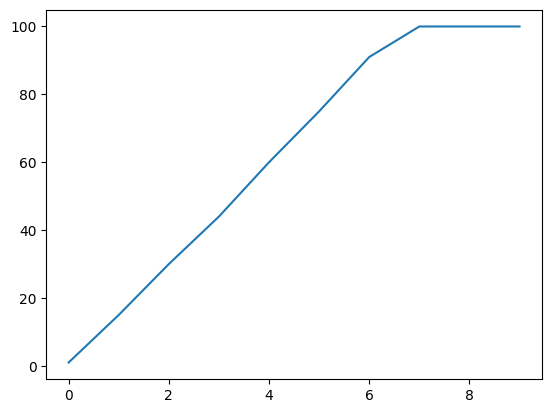

In [173]:
plt.plot(battery)